In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
import os
import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from PIL import Image
import pywt

PROJECT_DIR = "/content/drive/MyDrive/Multimedia_Authentication"

FACES_DIR = os.path.join(
    PROJECT_DIR,
    "faces"
)

PROCESSED_SPLIT_FILE = os.path.join(
    PROJECT_DIR,
    "splits",
    "ffpp_2647_processed_split.csv"
)

print("Project:", PROJECT_DIR)
print("Faces:", FACES_DIR)
print("Split file:", PROCESSED_SPLIT_FILE)

print("Faces directory exists:", os.path.exists(FACES_DIR))
print("Split file exists:", os.path.exists(PROCESSED_SPLIT_FILE))

Project: /content/drive/MyDrive/Multimedia_Authentication
Faces: /content/drive/MyDrive/Multimedia_Authentication/faces
Split file: /content/drive/MyDrive/Multimedia_Authentication/splits/ffpp_2647_processed_split.csv
Faces directory exists: True
Split file exists: True


In [23]:
df = pd.read_csv(PROCESSED_SPLIT_FILE)

def make_output_name(file_path):
    return file_path.replace("/", "__").replace("\\", "__").replace(".mp4", ".npz")

df["face_file"] = df["File Path"].apply(make_output_name)

face_files = {
    f for f in os.listdir(FACES_DIR)
    if f.endswith(".npz")
}

df["face_exists"] = df["face_file"].isin(face_files)

train_df = df[
    (df["split"] == "train") &
    (df["face_exists"])
].copy()

val_df = df[
    (df["split"] == "val") &
    (df["face_exists"])
].copy()

test_df = df[
    (df["split"] == "test") &
    (df["face_exists"])
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 1770
Validation: 392
Test: 418


In [24]:
face_files = {
    f for f in os.listdir(FACES_DIR)
    if f.endswith(".npz")
}

print("Actual face NPZ files:", len(face_files))

Actual face NPZ files: 2580


In [25]:
def make_output_name(file_path):
    return file_path.replace("/", "__").replace("\\", "__").replace(".mp4", ".npz")


df["face_file"] = df["File Path"].apply(make_output_name)

df["face_exists"] = df["face_file"].isin(face_files)

print("\nFace files available:")
print(df["face_exists"].value_counts())

print("\nMissing face files by split:")
print(
    df.loc[~df["face_exists"], "split"]
    .value_counts()
)

print("\nMissing face files by label:")
print(
    df.loc[~df["face_exists"], "Label"]
    .value_counts()
)


Face files available:
face_exists
True     2580
False      67
Name: count, dtype: int64

Missing face files by split:
split
train    52
val       9
test      6
Name: count, dtype: int64

Missing face files by label:
Label
FAKE    61
REAL     6
Name: count, dtype: int64


In [26]:
sample_row = df[df["face_exists"]].iloc[0]

face_path = os.path.join(
    FACES_DIR,
    sample_row["face_file"]
)

data = np.load(face_path)

print("Video:", sample_row["File Path"])
print("Label:", sample_row["Label"])
print("Split:", sample_row["split"])
print("NPZ keys:", data.files)

frames = data["frames"]

print("Frames shape:", frames.shape)
print("Frames dtype:", frames.dtype)
print("Min:", frames.min())
print("Max:", frames.max())

Video: FaceShifter/424_408.mp4
Label: FAKE
Split: train
NPZ keys: ['frames']
Frames shape: (8, 224, 224, 3)
Frames dtype: uint8
Min: 0
Max: 221


In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import pywt
from PIL import Image

import time
import copy

In [28]:
def dwt_high_frequency(frame):
    """
    Convert an RGB face frame into a 3-channel
    high-frequency representation using Haar DWT.

    Input:
        frame: (224, 224, 3), uint8

    Output:
        frequency_image: (224, 224, 3), float32
    """

    frame = frame.astype(np.float32) / 255.0

    channels = []

    for c in range(3):

        channel = frame[:, :, c]

        LL, (LH, HL, HH) = pywt.dwt2(
            channel,
            "haar"
        )

        channels.append(LH)
        channels.append(HL)
        channels.append(HH)

    # For the baseline, average the RGB-derived
    # high-frequency information for each subband.
    LH = np.mean(
        np.stack([channels[0], channels[3], channels[6]]),
        axis=0
    )

    HL = np.mean(
        np.stack([channels[1], channels[4], channels[7]]),
        axis=0
    )

    HH = np.mean(
        np.stack([channels[2], channels[5], channels[8]]),
        axis=0
    )

    frequency_image = np.stack(
        [LH, HL, HH],
        axis=-1
    )

    return frequency_image.astype(np.float32)

In [29]:
def normalize_frequency_image(freq_img):

    min_val = freq_img.min()
    max_val = freq_img.max()

    freq_img = (
        freq_img - min_val
    ) / (
        max_val - min_val + 1e-8
    )

    freq_img = (
        freq_img * 255
    ).clip(0, 255).astype(np.uint8)

    return Image.fromarray(freq_img)

In [30]:
sample_frames = np.load(face_path)["frames"]

sample_frame = sample_frames[0]

freq = dwt_high_frequency(sample_frame)

print("Original shape:", sample_frame.shape)
print("DWT shape:", freq.shape)
print("DWT min:", freq.min())
print("DWT max:", freq.max())

Original shape: (224, 224, 3)
DWT shape: (112, 112, 3)
DWT min: -0.36993465
DWT max: 0.32549024


In [31]:
freq_image = normalize_frequency_image(freq)

print("Frequency image size:", freq_image.size)

Frequency image size: (112, 112)


In [32]:
freq_image = freq_image.resize(
    (224, 224)
)

print(freq_image.size)

(224, 224)


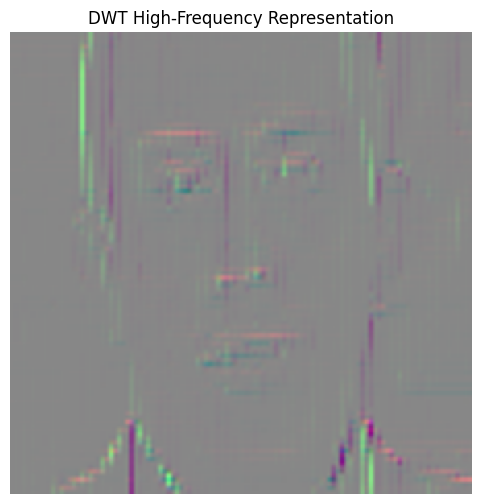

In [33]:
plt.figure(figsize=(6, 6))

plt.imshow(freq_image)

plt.axis("off")
plt.title("DWT High-Frequency Representation")

plt.show()

In [34]:
class FrequencySequenceDataset(Dataset):

    def __init__(self, dataframe, faces_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.faces_dir = faces_dir
        self.transform = transform

        self.label_map = {
            "REAL": 0,
            "FAKE": 1
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        npz_name = make_output_name(row["File Path"])
        npz_path = os.path.join(
            self.faces_dir,
            npz_name
        )

        data = np.load(npz_path)
        frames = data["frames"]

        processed_frames = []

        for frame in frames:

            # RGB → high-frequency DWT representation
            freq = dwt_high_frequency(frame)

            # Normalize DWT coefficients
            freq_image = normalize_frequency_image(freq)

            # Resize 112×112 → 224×224
            freq_image = freq_image.resize(
                (224, 224)
            )

            if self.transform:
                freq_image = self.transform(freq_image)

            processed_frames.append(freq_image)

        # [8, 3, 224, 224]
        frames = torch.stack(processed_frames)

        label = self.label_map[row["Label"]]

        return frames, torch.tensor(
            label,
            dtype=torch.long
        )

In [35]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
frequency_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [36]:
freq_train_dataset = FrequencySequenceDataset(
    train_df,
    FACES_DIR,
    transform=frequency_transform
)

freq_val_dataset = FrequencySequenceDataset(
    val_df,
    FACES_DIR,
    transform=frequency_transform
)

freq_test_dataset = FrequencySequenceDataset(
    test_df,
    FACES_DIR,
    transform=frequency_transform
)

print("Train:", len(freq_train_dataset))
print("Validation:", len(freq_val_dataset))
print("Test:", len(freq_test_dataset))

Train: 1770
Validation: 392
Test: 418


In [37]:
freq_frames, freq_label = freq_train_dataset[0]

print("Frequency frames shape:", freq_frames.shape)
print("Frequency frames dtype:", freq_frames.dtype)
print("Label:", freq_label)

Frequency frames shape: torch.Size([8, 3, 224, 224])
Frequency frames dtype: torch.float32
Label: tensor(1)


In [38]:
freq_train_loader = DataLoader(
    freq_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

freq_val_loader = DataLoader(
    freq_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

freq_test_loader = DataLoader(
    freq_test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [39]:
batch_frames, batch_labels = next(iter(freq_train_loader))

print("Batch frames:", batch_frames.shape)
print("Batch labels:", batch_labels.shape)
print("Labels:", batch_labels)

Batch frames: torch.Size([8, 8, 3, 224, 224])
Batch labels: torch.Size([8])
Labels: tensor([1, 1, 1, 1, 0, 0, 0, 0])


In [40]:
freq_frames, freq_label = freq_train_dataset[0]

print("Frequency frames shape:", freq_frames.shape)
print("Frequency frames dtype:", freq_frames.dtype)
print("Label:", freq_label)

Frequency frames shape: torch.Size([8, 3, 224, 224])
Frequency frames dtype: torch.float32
Label: tensor(1)


In [41]:
class FrequencyResNet18(nn.Module):

    def __init__(self):
        super().__init__()

        resnet = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        self.backbone = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        """
        x:
        [batch, 8, 3, 224, 224]
        """

        batch_size, num_frames, C, H, W = x.shape

        x = x.view(
            batch_size * num_frames,
            C,
            H,
            W
        )

        features = self.backbone(x)

        features = features.view(
            batch_size,
            num_frames,
            512
        )

        # Aggregate the 8 frames
        video_features = features.mean(dim=1)

        logits = self.classifier(
            video_features
        )

        return logits

In [42]:
class FrequencyResNet18(nn.Module):

    def __init__(self):
        super().__init__()

        resnet = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        self.backbone = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        self.classifier = nn.Linear(512, 2)

    def forward(self, x):
        """
        x:
        [batch, 8, 3, 224, 224]
        """

        batch_size, num_frames, C, H, W = x.shape

        x = x.view(
            batch_size * num_frames,
            C,
            H,
            W
        )

        features = self.backbone(x)

        features = features.view(
            batch_size,
            num_frames,
            512
        )

        # Aggregate the 8 frames
        video_features = features.mean(dim=1)

        logits = self.classifier(
            video_features
        )

        return logits

In [43]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

freq_model = FrequencyResNet18().to(device)

print("Device:", device)
print("Model created successfully.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 95.7MB/s]


Device: cuda
Model created successfully.


In [44]:
class_counts = train_df["Label"].value_counts()

real_count = class_counts["REAL"]
fake_count = class_counts["FAKE"]

total = real_count + fake_count

freq_class_weights = torch.tensor(
    [
        total / (2 * real_count),
        total / (2 * fake_count)
    ],
    dtype=torch.float32
).to(device)

print("REAL weight:", freq_class_weights[0].item())
print("FAKE weight:", freq_class_weights[1].item())

REAL weight: 2.9697985649108887
FAKE weight: 0.601222813129425


In [45]:
freq_criterion = nn.CrossEntropyLoss(
    weight=freq_class_weights
)

freq_optimizer = torch.optim.AdamW(
    freq_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

freq_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    freq_optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import time
import copy


def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):

    model.train()

    running_loss = 0.0
    all_labels = []
    all_preds = []

    for frames, labels in loader:

        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.amp.autocast(device_type="cuda"):
                logits = model(frames)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            logits = model(frames)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * labels.size(0)

        preds = torch.argmax(logits, dim=1)

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(loader.dataset)

    epoch_acc = accuracy_score(
        all_labels,
        all_preds
    )

    return epoch_loss, epoch_acc

In [52]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for frames, labels in loader:

            frames = frames.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(frames)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            probs = torch.softmax(
                logits,
                dim=1
            )[:, 1]

            preds = torch.argmax(
                logits,
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    epoch_loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    auc = roc_auc_score(
        all_labels,
        all_probs
    )

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

In [53]:
NUM_EPOCHS = 10

freq_scaler = torch.amp.GradScaler("cuda")

best_freq_val_f1 = -1
best_freq_epoch = 0
best_freq_model_state = None

freq_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_precision": [],
    "val_recall": [],
    "val_f1": [],
    "val_auc": []
}

start_time = time.time()

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    train_loss, train_acc = train_one_epoch(
        freq_model,
        freq_train_loader,
        freq_criterion,
        freq_optimizer,
        device,
        freq_scaler
    )

    val_metrics = evaluate(
        freq_model,
        freq_val_loader,
        freq_criterion,
        device
    )

    freq_scheduler.step(
        val_metrics["loss"]
    )

    freq_history["train_loss"].append(train_loss)
    freq_history["train_acc"].append(train_acc)

    freq_history["val_loss"].append(
        val_metrics["loss"]
    )

    freq_history["val_acc"].append(
        val_metrics["accuracy"]
    )

    freq_history["val_precision"].append(
        val_metrics["precision"]
    )

    freq_history["val_recall"].append(
        val_metrics["recall"]
    )

    freq_history["val_f1"].append(
        val_metrics["f1"]
    )

    freq_history["val_auc"].append(
        val_metrics["auc"]
    )

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Time: {epoch_time:.1f}s | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.4f} | "
        f"Val Precision: {val_metrics['precision']:.4f} | "
        f"Val Recall: {val_metrics['recall']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | "
        f"Val AUC: {val_metrics['auc']:.4f}"
    )

    if val_metrics["f1"] > best_freq_val_f1:

        best_freq_val_f1 = val_metrics["f1"]
        best_freq_epoch = epoch + 1

        best_freq_model_state = copy.deepcopy(
            freq_model.state_dict()
        )

        torch.save(
            {
                "epoch": best_freq_epoch,
                "model_state_dict": freq_model.state_dict(),
                "optimizer_state_dict": freq_optimizer.state_dict(),
                "val_f1": best_freq_val_f1
            },
            os.path.join(
                PROJECT_DIR,
                "frequency_resnet18_best.pth"
            )
        )

        print("  ✓ Best frequency model saved")

total_time = time.time() - start_time

print("\nFrequency training complete.")
print(
    f"Total training time: "
    f"{total_time / 60:.2f} minutes"
)
print(
    f"Best validation F1: "
    f"{best_freq_val_f1:.4f}"
)
print(
    f"Best epoch: {best_freq_epoch}"
)

Epoch [1/10] | Time: 143.6s | Train Loss: 0.7456 | Train Acc: 0.6345 | Val Loss: 0.8330 | Val Acc: 0.7041 | Val Precision: 0.8250 | Val Recall: 0.8148 | Val F1: 0.8199 | Val AUC: 0.5149
  ✓ Best frequency model saved
Epoch [2/10] | Time: 111.6s | Train Loss: 0.6972 | Train Acc: 0.7153 | Val Loss: 0.8899 | Val Acc: 0.8265 | Val Precision: 0.8265 | Val Recall: 1.0000 | Val F1: 0.9050 | Val AUC: 0.6028
  ✓ Best frequency model saved
Epoch [3/10] | Time: 116.7s | Train Loss: 0.6773 | Train Acc: 0.7215 | Val Loss: 0.6994 | Val Acc: 0.7066 | Val Precision: 0.8255 | Val Recall: 0.8179 | Val F1: 0.8217 | Val AUC: 0.5858
Epoch [4/10] | Time: 110.8s | Train Loss: 0.6636 | Train Acc: 0.7181 | Val Loss: 0.6836 | Val Acc: 0.8163 | Val Precision: 0.8333 | Val Recall: 0.9722 | Val F1: 0.8974 | Val AUC: 0.6703
Epoch [5/10] | Time: 110.5s | Train Loss: 0.6127 | Train Acc: 0.7531 | Val Loss: 0.6408 | Val Acc: 0.7857 | Val Precision: 0.8488 | Val Recall: 0.9012 | Val F1: 0.8743 | Val AUC: 0.6934
Epoch [6

In [54]:
checkpoint = torch.load(
    os.path.join(
        PROJECT_DIR,
        "frequency_resnet18_best.pth"
    ),
    map_location=device
)

freq_model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Loaded best model from epoch:",
    checkpoint["epoch"]
)

Loaded best model from epoch: 2


In [55]:
checkpoint = torch.load(
    os.path.join(
        PROJECT_DIR,
        "frequency_resnet18_best.pth"
    ),
    map_location=device
)

freq_model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Loaded best model from epoch:",
    checkpoint["epoch"]
)

Loaded best model from epoch: 2


In [56]:
freq_test_metrics = evaluate(
    freq_model,
    freq_test_loader,
    freq_criterion,
    device
)

print("\n===== FREQUENCY RESNET18 TEST RESULTS =====")

print(
    f"Accuracy : "
    f"{freq_test_metrics['accuracy']:.4f}"
)

print(
    f"Precision: "
    f"{freq_test_metrics['precision']:.4f}"
)

print(
    f"Recall   : "
    f"{freq_test_metrics['recall']:.4f}"
)

print(
    f"F1 Score : "
    f"{freq_test_metrics['f1']:.4f}"
)

print(
    f"ROC-AUC  : "
    f"{freq_test_metrics['auc']:.4f}"
)


===== FREQUENCY RESNET18 TEST RESULTS =====
Accuracy : 0.8469
Precision: 0.8469
Recall   : 1.0000
F1 Score : 0.9171
ROC-AUC  : 0.5784


In [57]:
freq_cm = confusion_matrix(
    freq_test_metrics["labels"],
    freq_test_metrics["preds"]
)

print("Frequency Confusion Matrix:")
print(freq_cm)

Frequency Confusion Matrix:
[[  0  64]
 [  0 354]]


Spatial ResNet18:
Accuracy = 0.8517
Precision = 0.9101
Recall = 0.9153
F1 = 0.9127
ROC-AUC = 0.8050

Frequency DWT + ResNet18:
Accuracy = 0.8469
Precision = 0.8469
Recall = 1.0000
F1 = 0.9171
ROC-AUC = 0.5784

Frequency confusion matrix:
[[0, 64],
 [0, 354]]